# Combined selection-rule diagrams
The original two diagrams are arranged vertically as panels **(a)** and **(b)**.


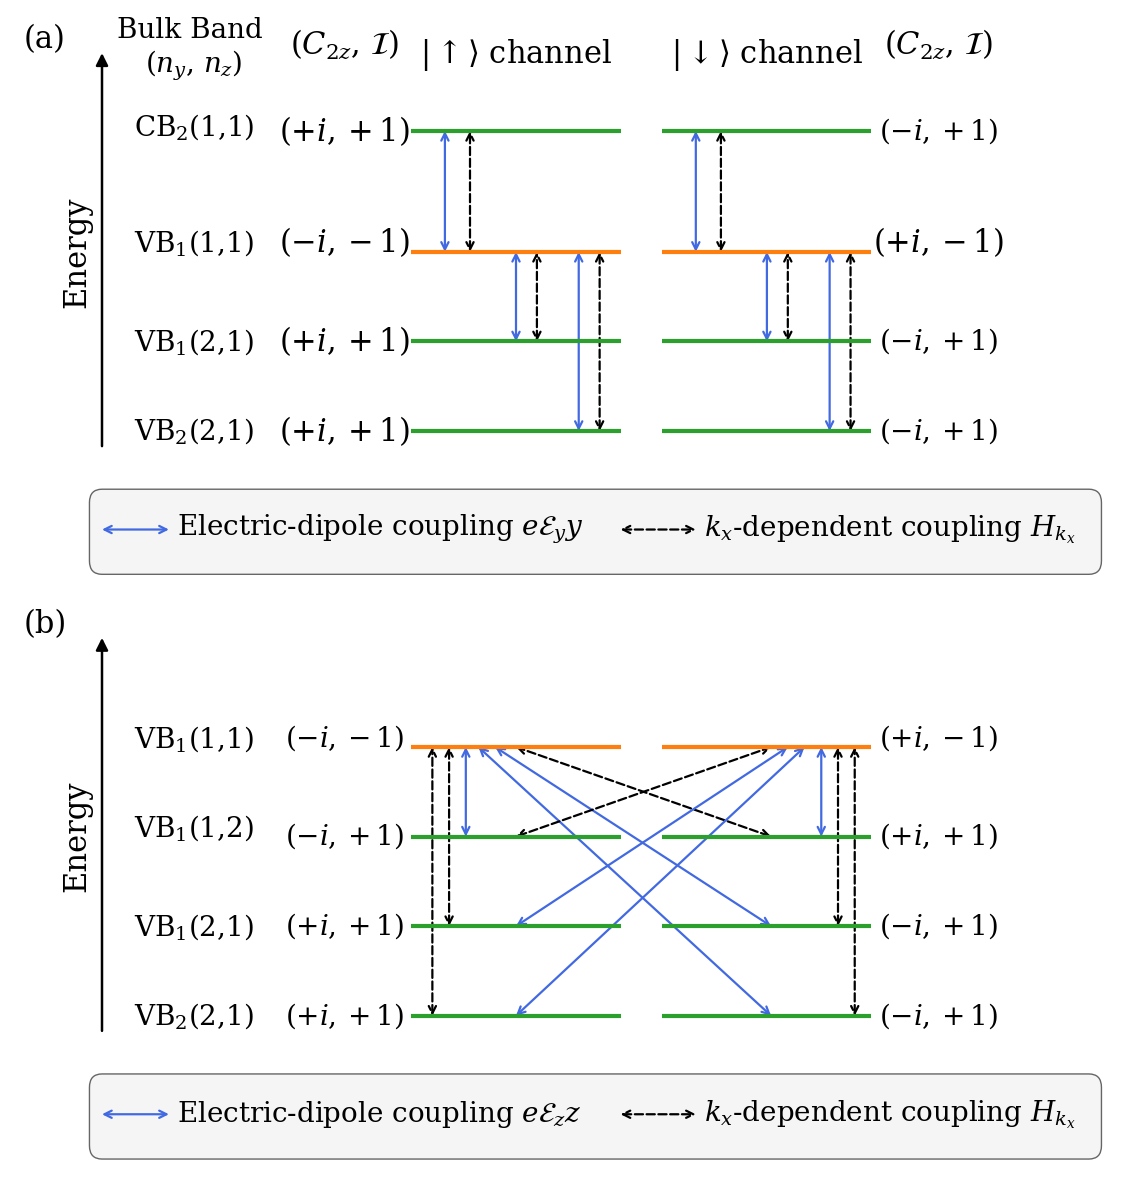

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

plt.rcParams.update({
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
    "font.size": 20
})

# ==================================================
# Helper functions
# ==================================================
def add_level(ax, x1, x2, y, color, lw=3):
    ax.plot([x1, x2], [y, y], color=color, lw=lw,
            solid_capstyle="butt")


def add_double_arrow(
    ax, x1, y1, x2, y2, color="black", lw=1.6,
    linestyle="-", label=None, label_pos=0.5,
    label_offset=(0.0, 0.0)
):
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="<->",
        mutation_scale=13,
        linewidth=lw,
        linestyle=linestyle,
        color=color,
        shrinkA=0,
        shrinkB=0
    )
    ax.add_patch(arrow)

    if label is not None:
        xm = x1 + label_pos * (x2 - x1) + label_offset[0]
        ym = y1 + label_pos * (y2 - y1) + label_offset[1]
        ax.text(xm, ym, label, fontsize=13,
                ha="center", va="center")


def setup_panel(ax, panel_label):
    """Set the common coordinate range, energy axis, and panel label."""
    ax.set_xlim(-8.8, 4.4)
    ax.set_ylim(-3.7, 2.7)
    ax.axis("off")

    energy_axis = FancyArrowPatch(
        (-7.7, -2.2), (-7.7, 2.25),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.8,
        color="black"
    )
    ax.add_patch(energy_axis)

    ax.text(
        -8.0, 0.0, "Energy",
        rotation=90,
        fontsize=22,
        ha="center",
        va="center"
    )

    ax.text(
        0.012, 0.975, panel_label,
        transform=ax.transAxes,
        fontsize=22,
        ha="left",
        va="top"
    )


def add_legend_box(ax, electric_label):
    """Add the common legend box at the bottom of a panel."""
    box_x, box_y = -7.7, -3.45
    box_w, box_h = 11.8, 0.65

    legend_box = FancyBboxPatch(
        (box_x, box_y), box_w, box_h,
        boxstyle="round,pad=0.15,rounding_size=0.0",
        linewidth=1.0,
        edgecolor="0.4",
        facecolor="0.96"
    )
    ax.add_patch(legend_box)

    add_double_arrow(
        ax, -7.7, -3.10, -6.9, -3.10,
        color="royalblue", linestyle="-"
    )
    ax.text(
        -6.8, -3.10,
        electric_label,
        fontsize=20,
        ha="left",
        va="center"
    )

    add_double_arrow(
        ax, -1.5, -3.10, -0.6, -3.10,
        color="black", linestyle="--"
    )
    ax.text(
        -0.5, -3.10,
        r"$k_x$-dependent coupling $H_{k_x}$",
        fontsize=20,
        ha="left",
        va="center"
    )


# ==================================================
# Panel (a): E_y selection-rule diagram
# ==================================================
def draw_ey_panel(ax):
    setup_panel(ax, "(a)")

    orange = "tab:orange"
    green = "tab:green"
    blue = "royalblue"
    black = "black"

    # Left channel: |up>
    ax.text(-2.75, 2.2, r"$|\uparrow\rangle$ channel",
            fontsize=22, ha="center", va="center")

    add_level(ax, -4.0, -1.5, 0.0, orange)

    left_levels = [1.35, -1.0, -2.0]
    for y in left_levels:
        add_level(ax, -4.0, -1.5, y, green)

    add_double_arrow(ax, -3.6, 0.0, -3.6, 1.35,
                     color=blue, linestyle="-")
    add_double_arrow(ax, -3.30, 0.0, -3.30, 1.35,
                     color=black, linestyle="--")
    add_double_arrow(ax, -2.75, -1.0, -2.75, 0.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, -2.50, -1.0, -2.50, 0.0,
                     color=black, linestyle="--")
    add_double_arrow(ax, -2.00, -2.0, -2.00, 0.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, -1.75, -2.0, -1.75, 0.0,
                     color=black, linestyle="--")

    # Right channel: |down>
    ax.text(0.25, 2.2, r"$|\downarrow\rangle$ channel",
            fontsize=22, ha="center", va="center")

    add_level(ax, -1.0, 1.5, 0.0, orange)

    right_levels = [1.35, -1.0, -2.0]
    for y in right_levels:
        add_level(ax, -1.0, 1.5, y, green)

    add_double_arrow(ax, -0.6, 0.0, -0.6, 1.35,
                     color=blue, linestyle="-")
    add_double_arrow(ax, -0.30, 0.0, -0.30, 1.35,
                     color=black, linestyle="--")
    add_double_arrow(ax, 0.25, -1.0, 0.25, 0.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, 0.50, -1.0, 0.50, 0.0,
                     color=black, linestyle="--")
    add_double_arrow(ax, 1.00, -2.0, 1.00, 0.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, 1.25, -2.0, 1.25, 0.0,
                     color=black, linestyle="--")

    # Symmetry labels
    ax.text(-4.8, 2.2, r"$(C_{2z}$, $\mathcal{I}$)",
            fontsize=22, ha="center")
    ax.text(-4.8, 0.0, r"$(-i,-1)$", fontsize=22, ha="center")

    for y in left_levels:
        ax.text(-4.8, y, r"($+i, +1)$",
                fontsize=22, ha="center", va="center")

    ax.text(2.3, 2.2, r"($C_{2z}$, $\mathcal{I}$)",
            fontsize=22, ha="center")
    ax.text(2.3, 0.0, r"($+i,-1)$", fontsize=22, ha="center")

    for y in right_levels:
        ax.text(2.3, y, r"($-i, +1)$",
                fontsize=20, ha="center", va="center")

    # Subband labels
    ax.text(-6.6, 2.0, "Bulk Band \n" + r"($n_y$, $n_z$)",
            fontsize=20, ha="center")
    ax.text(-6.6, 0.0, r"VB$_1$(1,1)", fontsize=20, ha="center")
    ax.text(-6.6, 1.3, r"CB$_2$(1,1)", fontsize=20, ha="center")
    ax.text(-6.6, -1.1, r"VB$_1$(2,1)", fontsize=20, ha="center")
    ax.text(-6.6, -2.1, r"VB$_2$(2,1)", fontsize=20, ha="center")

    add_legend_box(
        ax,
        r"Electric-dipole coupling $e\mathcal{E}_y y$"
    )


# ==================================================
# Panel (b): E_z selection-rule diagram
# ==================================================
def draw_ez_panel(ax):
    setup_panel(ax, "(b)")

    orange = "tab:orange"
    green = "tab:green"
    blue = "royalblue"
    black = "black"

    # Left channel: |up>
    # ax.text(-2.75, 2.15, r"$|\uparrow\rangle$ channel",
            # fontsize=20, ha="center", va="center")

    add_level(ax, -4.0, -1.5, 1.0, orange)

    left_levels = [0.0, -1.0, -2.0]
    for y in left_levels:
        add_level(ax, -4.0, -1.5, y, green)

    add_double_arrow(ax, -3.35, 0.0, -3.35, 1.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, 0.30, 0.0, -2.75, 1.0,
                     color=black, linestyle="--")
    add_double_arrow(ax, 0.3, -1.0, -3.0, 1.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, -3.55, -1.0, -3.55, 1.0,
                     color=black, linestyle="--")
    add_double_arrow(ax, 0.3, -2.0, -3.2, 1.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, -3.75, -2.0, -3.75, 1.0,
                     color=black, linestyle="--")

    # Right channel: |down>
    # ax.text(0.25, 2.15, r"$|\downarrow\rangle$ channel",
            # fontsize=20, ha="center", va="center")

    add_level(ax, -1.0, 1.5, 1.0, orange)

    right_levels = [0.0, -1.0, -2.0]
    for y in right_levels:
        add_level(ax, -1.0, 1.5, y, green)

    add_double_arrow(ax, 0.9, 0.0, 0.9, 1.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, -2.75, 0.0, 0.3, 1.0,
                     color=black, linestyle="--")
    add_double_arrow(ax, -2.75, -1.0, 0.5, 1.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, 1.1, -1.0, 1.1, 1.0,
                     color=black, linestyle="--")
    add_double_arrow(ax, -2.75, -2.0, 0.70, 1.0,
                     color=blue, linestyle="-")
    add_double_arrow(ax, 1.3, -2.0, 1.3, 1.0,
                     color=black, linestyle="--")

    # Symmetry labels
    # ax.text(-4.8, 1.7, r"$(C_{2z}$, $\mathcal{I}$)",
            # fontsize=20, ha="center")
    ax.text(-4.8, 1.0, r"$(-i,-1)$", fontsize=20, ha="center")
    ax.text(-4.8, 0.0, r"($-i, +1)$",
            fontsize=20, ha="center", va="center")
    ax.text(-4.8, -1.0, r"($+i, +1)$",
            fontsize=20, ha="center", va="center")
    ax.text(-4.8, -2.0, r"($+i, +1)$",
            fontsize=20, ha="center", va="center")

    # ax.text(2.3, 1.7, r"($C_{2z}$, $\mathcal{I}$)",
            # fontsize=20, ha="center")
    ax.text(2.3, 1.0, r"($+i,-1)$", fontsize=20, ha="center")
    ax.text(2.3, 0.0, r"($+i, +1)$",
            fontsize=20, ha="center", va="center")
    ax.text(2.3, -1.0, r"($-i, +1)$",
            fontsize=20, ha="center", va="center")
    ax.text(2.3, -2.0, r"($-i, +1)$",
            fontsize=20, ha="center", va="center")

    # Subband labels
    # ax.text(-6.6, 2.0, "Bulk Band \n" + r"($n_y$, $n_z$)",
            # fontsize=20, ha="center")
    ax.text(-6.6, 1.0, r"VB$_1$(1,1)", fontsize=20, ha="center")
    ax.text(-6.6, 0.0, r"VB$_1$(1,2)", fontsize=20, ha="center")
    ax.text(-6.6, -1.1, r"VB$_1$(2,1)", fontsize=20, ha="center")
    ax.text(-6.6, -2.1, r"VB$_2$(2,1)", fontsize=20, ha="center")

    add_legend_box(
        ax,
        r"Electric-dipole coupling $e\mathcal{E}_z z$"
    )


# ==================================================
# Combined 2 x 1 figure
# ==================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(11.5, 12.0),
    gridspec_kw={"hspace": 0.02}
)

ax_a, ax_b = axes

draw_ey_panel(ax_a)
draw_ez_panel(ax_b)

fig.subplots_adjust(
    left=0.03,
    right=0.99,
    bottom=0.025,
    top=0.99,
    hspace=0.02
)

fig.savefig(
    "rashba_selection_rule_diagrams_2x1.png",
    dpi=600,
    bbox_inches="tight"
)
fig.savefig(
    "rashba_selection_rule_diagrams_2x1.pdf",
    bbox_inches="tight"
)
fig.savefig(
    "rashba_selection_rule_diagrams_2x1.svg",
    bbox_inches="tight"
)

plt.show()
